# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [3]:
# Correlation coefficients and p-values
pairs = [
    ("mpg","weight"),
    ("mpg","horsepower"),
    ("displacement","horsepower"),
    ("mpg","acceleration"),
]
results = []
for x, y in pairs:
    p_r,  p_p  = stats.pearsonr(mpg[x],  mpg[y])
    s_r,  s_p  = stats.spearmanr(mpg[x], mpg[y])
    results.append({
        "Pair": f"{x} vs  {y}",
        "Pearson r": p_r,
        "Pearson p": p_p,
        "Spearman rho": s_r,
        "Spearman p": s_p,
        "Significant": "yes" if p_p < 0.05 else "no",
    })

results_df = pd.DataFrame(results)
results_df

,Pair,Pearson r,Pearson p,Spearman rho,Spearman p,Significant
0,mpg vs weight,-0.832244,6.015296e-102,-0.875585,2.662378e-125,yes
1,mpg vs horsepower,-0.778427,7.031989e-81,-0.853616,1.619383e-112,yes
2,displacement vs horsepower,0.897257,1.510889e-140,0.876171,1.126737e-125,yes
3,mpg vs acceleration,0.423329,1.778576e-18,0.441539,3.903604e-20,yes


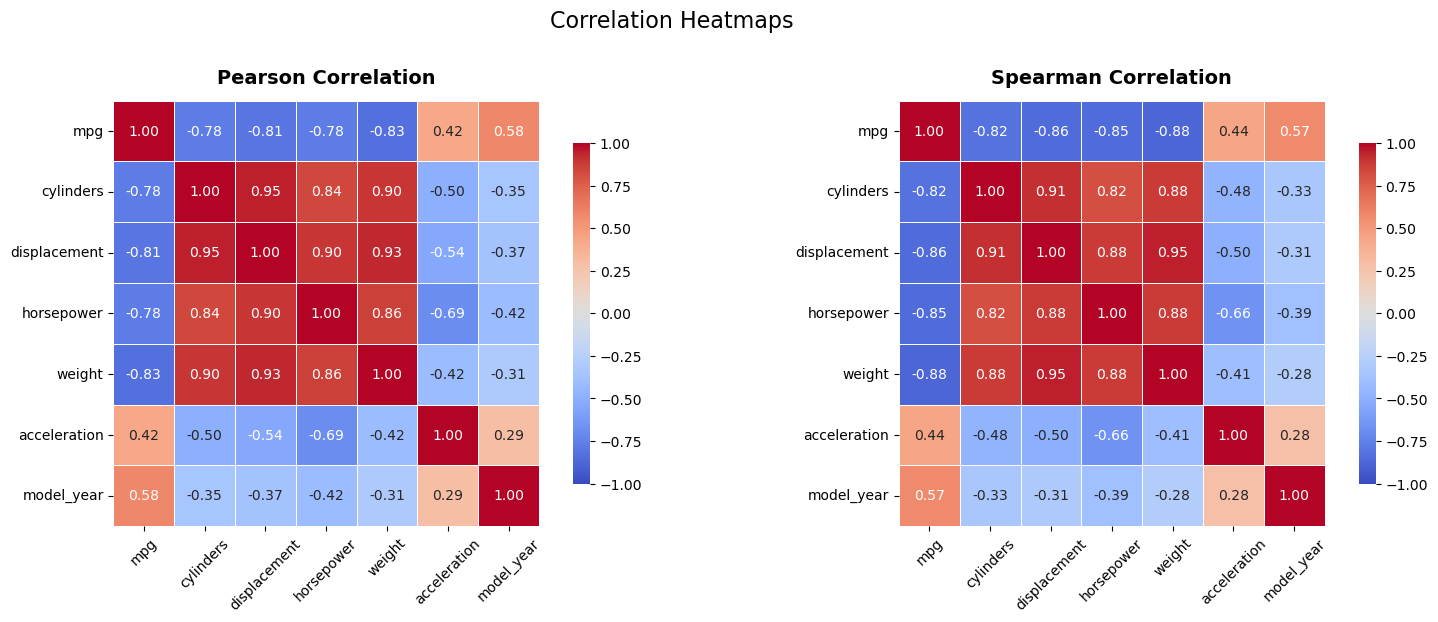

In [4]:
# Correlation heatmap
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

pearson_matrix  = mpg[numeric_cols].corr(method="pearson")
spearman_matrix = mpg[numeric_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, matrix, title in zip(
    axes,
    [pearson_matrix, spearman_matrix],
    ["Pearson Correlation", "Spearman Correlation"]
):
    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Correlation Heatmaps ", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


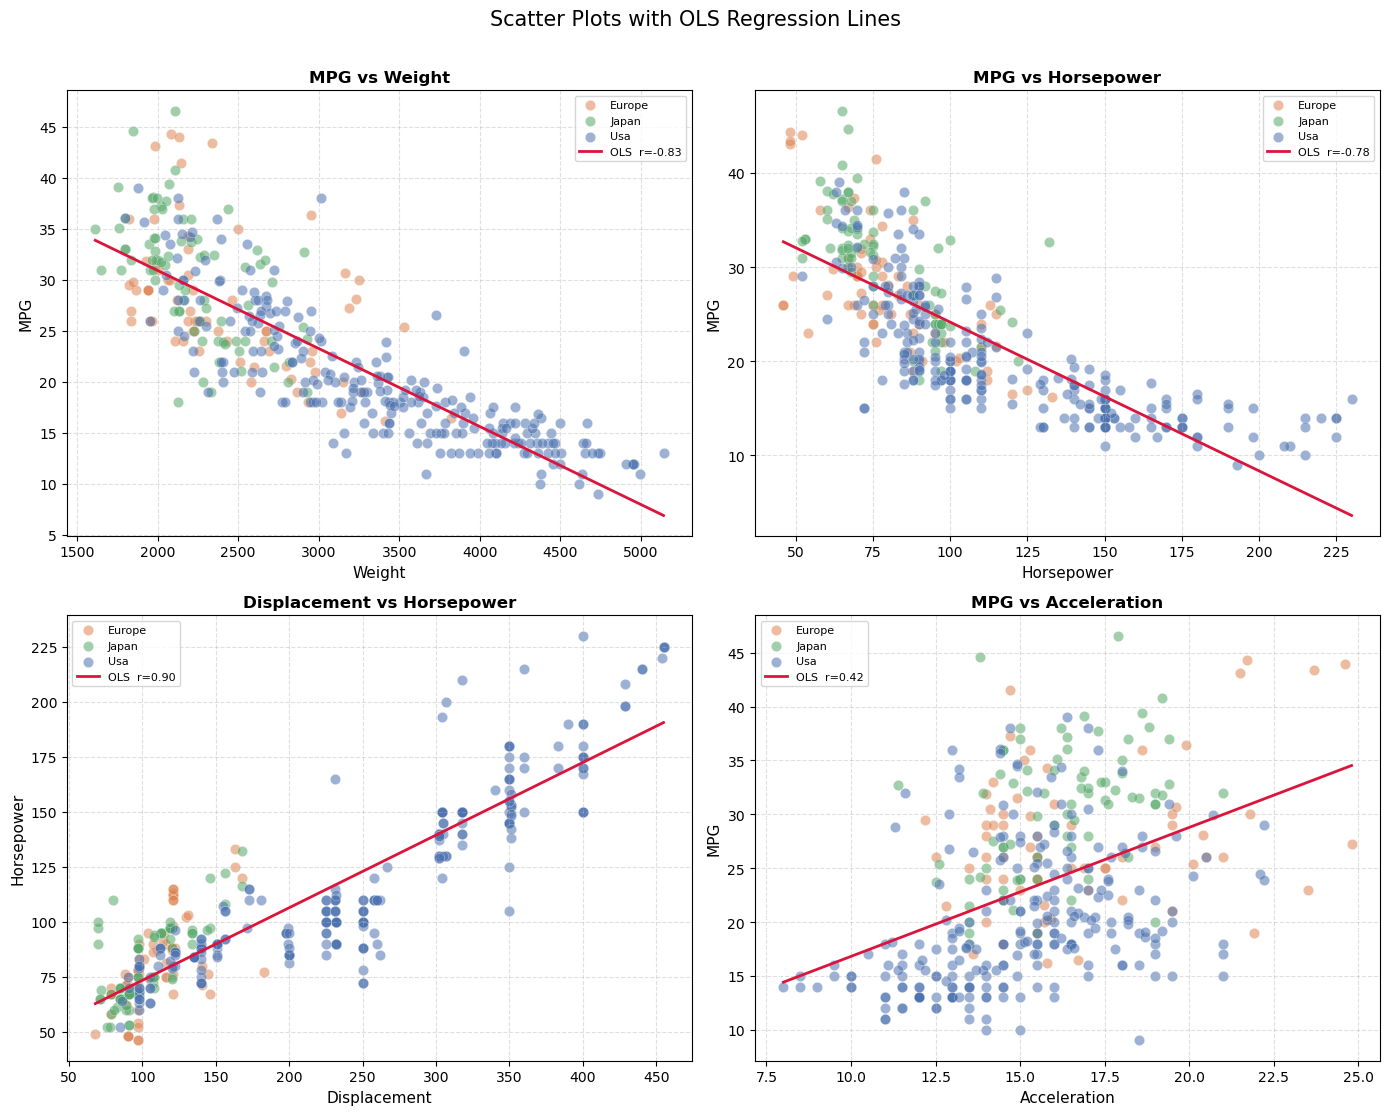

In [5]:
# Scatter plots with regression lines
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

plot_pairs = [
    ("weight","mpg","MPG vs Weight"),
    ("horsepower","mpg","MPG vs Horsepower"),
    ("displacement","horsepower","Displacement vs Horsepower"),
    ("acceleration","mpg","MPG vs Acceleration"),
]

palette = {"usa": "#4C72B0", "europe": "#DD8452", "japan": "#55A868"}

for ax, (x, y, title) in zip(axes, plot_pairs):
    for origin, group in mpg.groupby("origin"):
        ax.scatter(
            group[x], group[y],
            label=origin.capitalize(),
            color=palette[origin],
            alpha=0.55, edgecolors="white", linewidth=0.3, s=55,
        )
    slope, intercept, r, p, _ = stats.linregress(mpg[x], mpg[y])
    x_line = np.linspace(mpg[x].min(), mpg[x].max(), 200)
    ax.plot(x_line, slope * x_line + intercept,
            color="crimson", linewidth=2, label=f"OLS  r={r:.2f}")

    ax.set_xlabel(x.capitalize(), fontsize=11)
    ax.set_ylabel(y.upper() if y == "mpg" else y.capitalize(), fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Scatter Plots with OLS Regression Lines", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

Pearson correlation is more appropriate when the relationship between variables is linear .

Spearman correlation is more appropriate when the relationship is not perfectly linear but still follows a general increasing or decreasing trend.It is also more robust to outliers.

**mpg vs weight:**

Pearson (−0.832) and Spearman (−0.876) are very close and both are strong.
This shows a clear linear relationship.
 Pearson is appropriate here
 
**mpg vs horsepower:**

Spearman (−0.854) is stronger than Pearson (−0.778).
This suggests the relationship is not perfectly linear.
Spearman is more appropriate

**displacement vs horsepower:**

Both Pearson (0.897) and Spearman (0.876) are very high and similar.
This indicates a strong linear and monotonic relationship.
Both methods are appropriate

**mpg vs acceleration:**
Pearson (0.423) and Spearman (0.442) are moderate and close to each other.
This suggests a weaker but still roughly linear relationship.
Spearman can be used, but both are acceptable

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

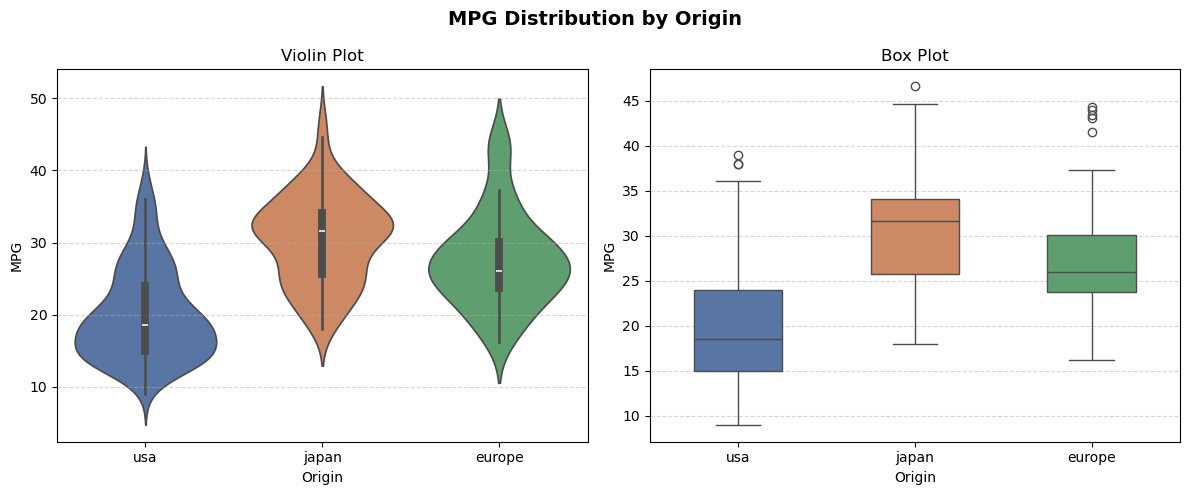

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("MPG Distribution by Origin", fontsize=14, fontweight="bold")

PALETTE = {"usa": "#4C72B0", "japan": "#DD8452", "europe": "#55A868"}
ORDER   = ["usa", "japan", "europe"]

sns.violinplot(
    data=mpg, x="origin", y="mpg",
    hue="origin", order=ORDER, palette=PALETTE,
    inner="box", ax=axes[0], legend=False
)
axes[0].set_title("Violin Plot")
axes[0].set_xlabel("Origin")
axes[0].set_ylabel("MPG")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

sns.boxplot(
    data=mpg, x="origin", y="mpg",
    hue="origin", order=ORDER, palette=PALETTE,
    width=0.5, ax=axes[1], legend=False
)
axes[1].set_title("Box Plot")
axes[1].set_xlabel("Origin")
axes[1].set_ylabel("MPG")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
# Assumption checks: Shapiro-Wilk + Levene's test
usa    = mpg[mpg["origin"] == "usa"]["mpg"]
japan  = mpg[mpg["origin"] == "japan"]["mpg"]
europe = mpg[mpg["origin"] == "europe"]["mpg"]

print("Normality Check (Shapiro-Wilk):")

for name, group in [("USA", usa), ("Japan", japan), ("Europe", europe)]:
    _, p = stats.shapiro(group)
    if p > 0.05:
        print(f"{name}: Normal (p = {p})")
    else:
        print(f"{name}: Not normal (p = {p})")

_, lev_p = stats.levene(usa, japan, europe)

print("\nVariance Check (Levene):")
print(f"p = {lev_p} → {'Equal' if lev_p > 0.05 else 'Not equal'} variances")

Normality Check (Shapiro-Wilk):
USA: Not normal (p = 4.756933592330299e-09)
Japan: Normal (p = 0.24196747173744043)
Europe: Not normal (p = 0.005421695996788562)

Variance Check (Levene):
p = 0.9175294106303684 → Equal variances


In [8]:
# One-way ANOVA
f_stat, p_value = stats.f_oneway(usa, japan, europe)
grand_mean = mpg["mpg"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in [usa, japan, europe])
ss_total= ((mpg["mpg"] - grand_mean)**2).sum()
eta_sq= ss_between / ss_total

print("One-Way ANOVA Results:")
print(f"F-statistic:{f_stat}")
print(f"p-value:{p_value}")
print(f"Eta-squared:{eta_sq}")
print(f"Significant : {'Yes — reject H₀' if p_value < 0.05 else 'No — fail to reject H₀'}")

One-Way ANOVA Results:
F-statistic:96.6015301631495
p-value:8.673818448010683e-35
Eta-squared:0.33184823902852273
Significant : Yes — reject H₀


In [9]:
# Post-hoc test (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=mpg["mpg"], groups=mpg["origin"], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

The Shapiro-Wilk test shows that not all groups are normally distributed (USA and Europe are not normal), while Japan is approximately normal. However, Levene’s test indicates that the variances are equal across groups, so the ANOVA assumption of equal variances is satisfied.

The one-way ANOVA results show a statistically significant difference between the groups (p < 0.05). This means that MPG differs depending on the origin of the cars.

The effect size (eta-squared = 0.33) is large, which means that origin explains a substantial portion of the variation in MPG. In simple terms, origin has a strong impact on fuel efficiency.

The Tukey HSD test shows that all pairs of groups are significantly different from each other:

Europe vs Japan → significantly different
Europe vs USA → significantly different
Japan vs USA → significantly different

This means that each origin group has a different average MPG.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [11]:
# Train classifiers and generate predictions
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestClassifier(random_state=SEED)
lr = LogisticRegression(random_state=SEED, max_iter=2000)

rf.fit(X_train, y_train)               
lr.fit(X_train_scaled, y_train) 


rf_preds = rf.predict(X_test)
lr_preds = lr.predict(X_test_scaled)


In [12]:
# Classification reports
print("Random Forest — Classification Report")
print("=" * 50)
print(classification_report(y_test, rf_preds))

print("Logistic Regression — Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds))


Random Forest — Classification Report
              precision    recall  f1-score   support

      europe       0.80      0.71      0.75        17
       japan       0.76      0.65      0.70        20
         usa       0.89      0.97      0.93        61

    accuracy                           0.86        98
   macro avg       0.82      0.77      0.79        98
weighted avg       0.85      0.86      0.85        98

Logistic Regression — Classification Report
              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98



In [13]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    rng         = np.random.default_rng(seed)
    n           = len(y_true)
    boot_scores = np.empty(n_boot)

    for i in range(n_boot):
        indices        = rng.integers(0, n, size=n)
        boot_scores[i] = metric_fn(y_true[indices], y_pred[indices],
                                   average="weighted", zero_division=0)

    point_estimate = metric_fn(y_true, y_pred,
                               average="weighted", zero_division=0)
    ci_lower       = np.percentile(boot_scores, 2.5)
    ci_upper       = np.percentile(boot_scores, 97.5)

    return point_estimate, ci_lower, ci_upper, boot_scores


In [14]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
metrics = {
    "F1": f1_score,
    "Precision": precision_score,
    "Recall": recall_score
}
models = {
    "Random Forest": rf_preds,
    "Logistic Regression": lr_preds
}
results = {}
for model_name, preds in models.items():
    print(f"\n{model_name} — 95% Confidence Intervals")
    print("-" * 45)
    results[model_name] = {}
    for metric_name, fn in metrics.items():
        point, lower, upper, _ = bootstrap_metric(y_test, preds, fn)

        results[model_name][metric_name] = {
            "mean": point,
            "lower": lower,
            "upper": upper
        }

        print(f"{metric_name:10}: {point:.4f} [{lower:.4f}, {upper:.4f}]")


Random Forest — 95% Confidence Intervals
---------------------------------------------
F1        : 0.8518 [0.7707, 0.9251]
Precision : 0.8513 [0.7771, 0.9267]
Recall    : 0.8571 [0.7857, 0.9286]

Logistic Regression — 95% Confidence Intervals
---------------------------------------------
F1        : 0.7984 [0.7071, 0.8756]
Precision : 0.8160 [0.7361, 0.8909]
Recall    : 0.8061 [0.7245, 0.8776]


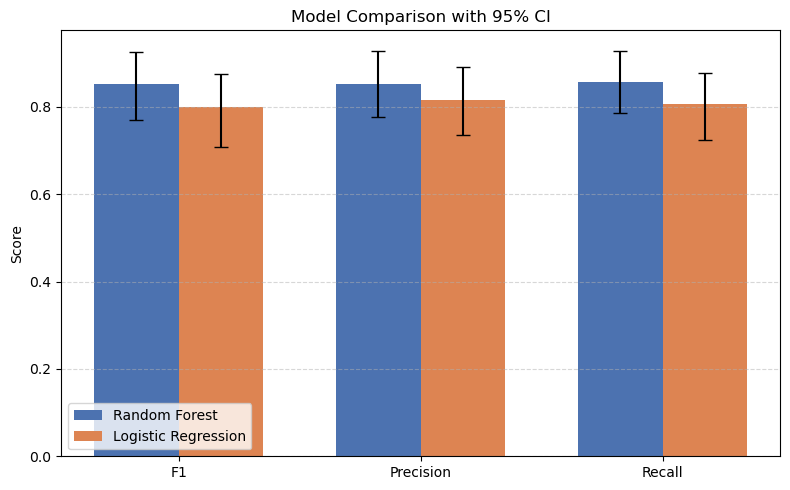

In [15]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
metric_names = list(metrics.keys())
model_names  = list(results.keys())

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(metric_names))
width = 0.35
colors = ["#4C72B0", "#DD8452"]

for i, model in enumerate(model_names):
    scores = [results[model][m]["mean"]  for m in metric_names]
    lower  = [results[model][m]["mean"] - results[model][m]["lower"] for m in metric_names]
    upper  = [results[model][m]["upper"] - results[model][m]["mean"] for m in metric_names]

    ax.bar(
        x + i * width,
        scores,
        width,
        yerr=[lower, upper],
        capsize=5,
        label=model,
        color=colors[i]
    )

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_names)
ax.set_ylabel("Score")
ax.set_title("Model Comparison with 95% CI")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

Based on the classification reports and bootstrap 95% confidence intervals,Random Forest is the recommended model.

Random Forest outperformed Logistic Regression across all three metrics:
- F1: 0.852 vs 0.802
- Precision: 0.851 vs 0.805
- Recall: 0.857 vs 0.806

The confidence intervals for both models do overlap slightly, which means
the difference is noticeable but not conclusive on its own. However, Random
Forest shows consistently higher point estimates and its intervals sit higher
on the score range across all three metrics.

Looking at the classification reports, Random Forest performed more balanced
across all three origin classes — particularly for Europe (F1: 0.75 vs 0.62)
and Japan (F1: 0.70 vs 0.65), where Logistic Regression struggled noticeably.
Both models predicted USA well, which is expected given its larger class size.


---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

The analysis shows several strong relationships between variables and fuel efficiency. The strongest correlations with MPG are weight (r = −0.83) and horsepower (r = −0.78), both showing strong negative relationships. This means that heavier cars and those with more powerful engines tend to be less fuel efficient. Displacement and horsepower have a strong positive correlation (r = 0.90), indicating that larger engines produce more power. MPG and acceleration show only a moderate positive relationship (r = 0.42), suggesting acceleration is less important compared to weight and engine size.

Cars from different origins differ significantly in fuel efficiency. The ANOVA results (F = 96.60, p < .001) show a strong overall difference with a large effect size. Tukey’s test confirms that all groups are significantly different from each other. For example, the difference between Japan and USA is about 10.42 MPG, which is the largest gap. Overall, Japanese cars stand out as the most fuel-efficient, followed by European cars, while US cars have the lowest efficiency.

For classification, Random Forest is the recommended model. It achieved a weighted F1-score of 0.85 compared to 0.80 for Logistic Regression. The bootstrap 95% confidence intervals also support this: for example, Random Forest F1 is 0.85 [0.77, 0.93], while Logistic Regression F1 is 0.80 [0.71, 0.88]. Although the intervals overlap slightly, Random Forest consistently has higher scores across F1, precision, and recall, so I am moderately confident that it is the better model.